In [155]:
library(tidyverse)
library(glue)

In [156]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] ggbreak_0.1.4   glue_1.7.0      lubridate_1.9.3 forcats_1.0.0  
 [5] stringr_1.5.1   dplyr_1.1.4     purrr_1.0.2     readr_2.1.5    
 [9] tidyr_1.3.1     tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 yulab.utils_0.2.0 
 [5] base64enc_0.1-3    tools_4.2.1        aplot_0.2.5        pkgload_1.4.0     
 [9] bit_4.0.5          digest_0.6.36      uuid_1.2-0         viridisLite_0.4.2 
[13] timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4   
[17] gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4 

In [191]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

In [201]:
consensus_to_original <- read_tsv("./data-preparation/global-alignment/combined_alignment_stats.tsv")%>%
    mutate(
        reference_distance = gsub("^(LVE\\d{5}-[RVDB0-9]{4})_.*", "\\1", seq1_id),
        index = gsub("^(LVE\\d{5}-[RVDB0-9]{4})_(.*).consensus.bcftools", "\\2", seq1_id),
        segment = ifelse(alignment_length > 5000, "L", "S"))
reference_to_original <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%
    mutate(reference_distance = glue("{query}-{fident_window_to_digits(fident_window)}"))

contig_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")

Rows: 252 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 125 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 464 Columns: 173
── Column specification ───────────────────────────────

In [202]:
consensus_vs_reference <- left_join(
    merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
    reference_to_original, by=c("reference_distance", "segment"), suffix=c("_consensus", "_reference"))%>%
    mutate(
        is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}", `(cluster) centroid`), FALSE, TRUE),
        is_RVDB_reference = ifelse(grepl("RVDB", reference_distance), TRUE, FALSE),
        fident = ifelse(is_RVDB_reference, 1, fident),
        # fident = ifelse(is.na(fident), 0, fident)
    )

dim(consensus_vs_reference)

[1] 252 204

In [203]:
head(consensus_vs_reference)

,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_bcftools,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_bcftools,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_bcftools,3443,1822,1798,33,0.018112,1891,⋯,67,3407,100,3347,3402,0,2308,"(0.68,0.7]",FALSE,FALSE
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_bcftools,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_bcftools,3443,1822,1798,33,0.018112,1891,⋯,67,3407,1,3248,3303,0,2512,"(0.72,0.74]",FALSE,FALSE
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_bcftools,LVE00045-RVDB_LVE00045_cl0_it2.consensus_bcftools,7264,7238,5935,3,0.000414,7263,⋯,6824,7241,64,6842,7264,0,7994,"(0.74,0.76]",TRUE,FALSE
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_bcftools,LVE00045-RVDB_LVE00045_cl0_it2.consensus_bcftools,7242,7167,6134,0,0.000000,7167,⋯,6824,7241,23,6802,7167,0,8301,"(0.76,0.78]",TRUE,FALSE


Warning message:
“Removed 164 rows containing missing values or values outside the scale range
(`geom_point()`).”


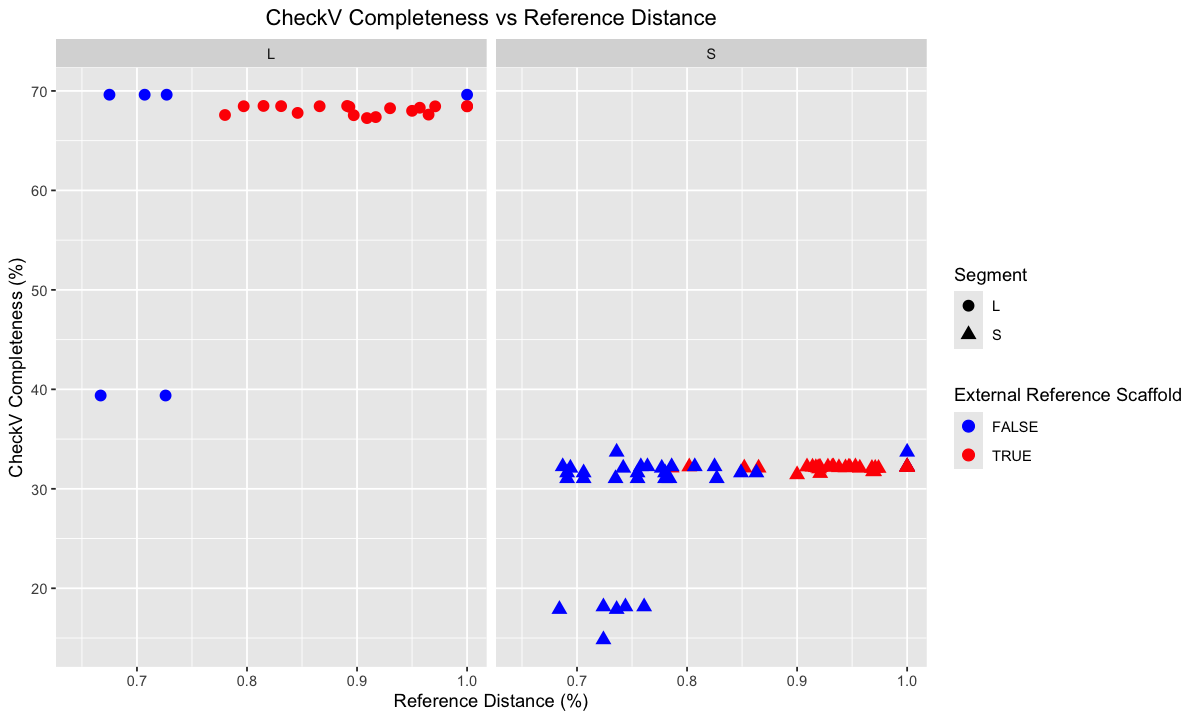

In [204]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(consensus_vs_reference, aes(x=fident, y=`(checkv) completeness`, color=is_external_reference_scaffold, shape=segment)) +
    geom_point(size=3) +
    facet_wrap(~segment) +
    labs(x="Reference Distance (%)", y="CheckV Completeness (%)", color="External Reference Scaffold", shape="Segment") +
    scale_color_manual(values=c("TRUE"="red", "FALSE"="blue")) +
    ggtitle("CheckV Completeness vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


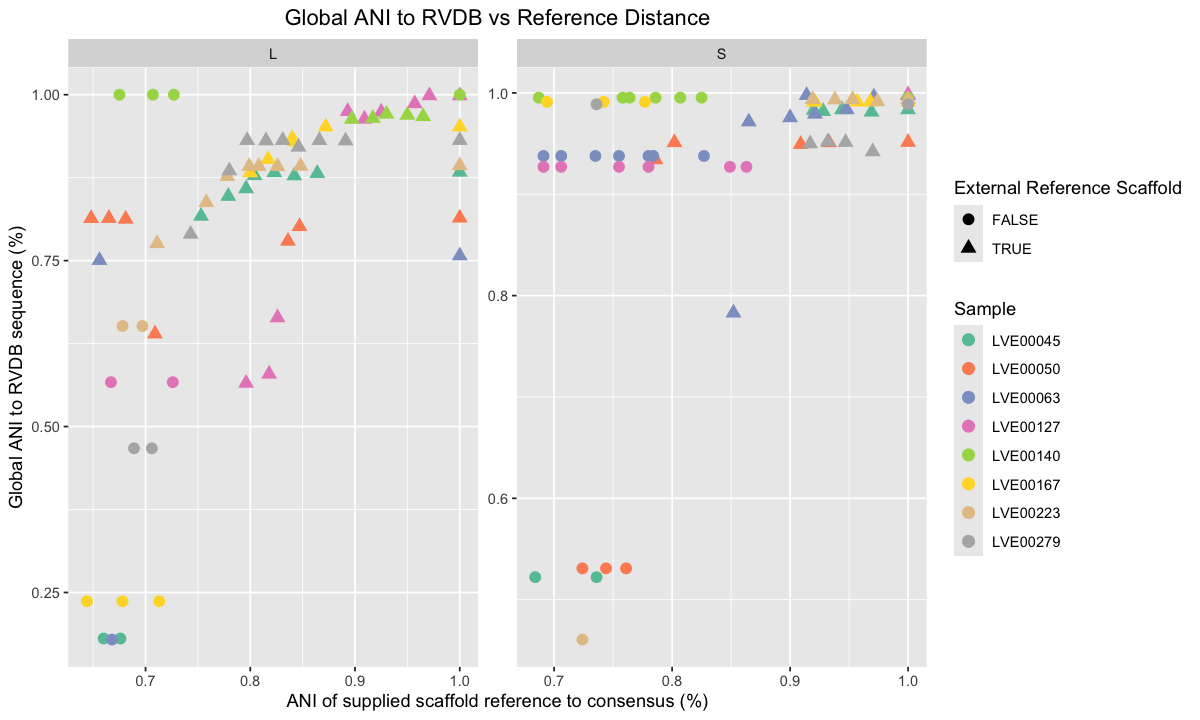

In [205]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


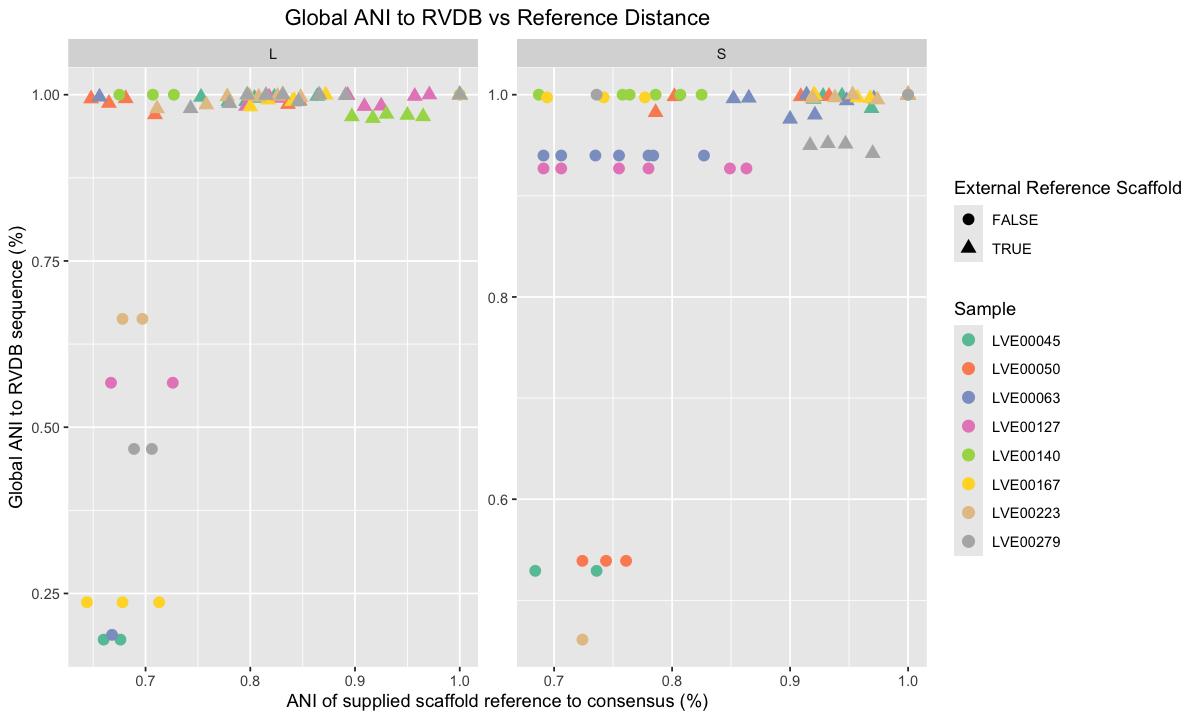

In [206]:
ggplot(consensus_vs_reference, aes(x=fident, y=comparable_sites/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


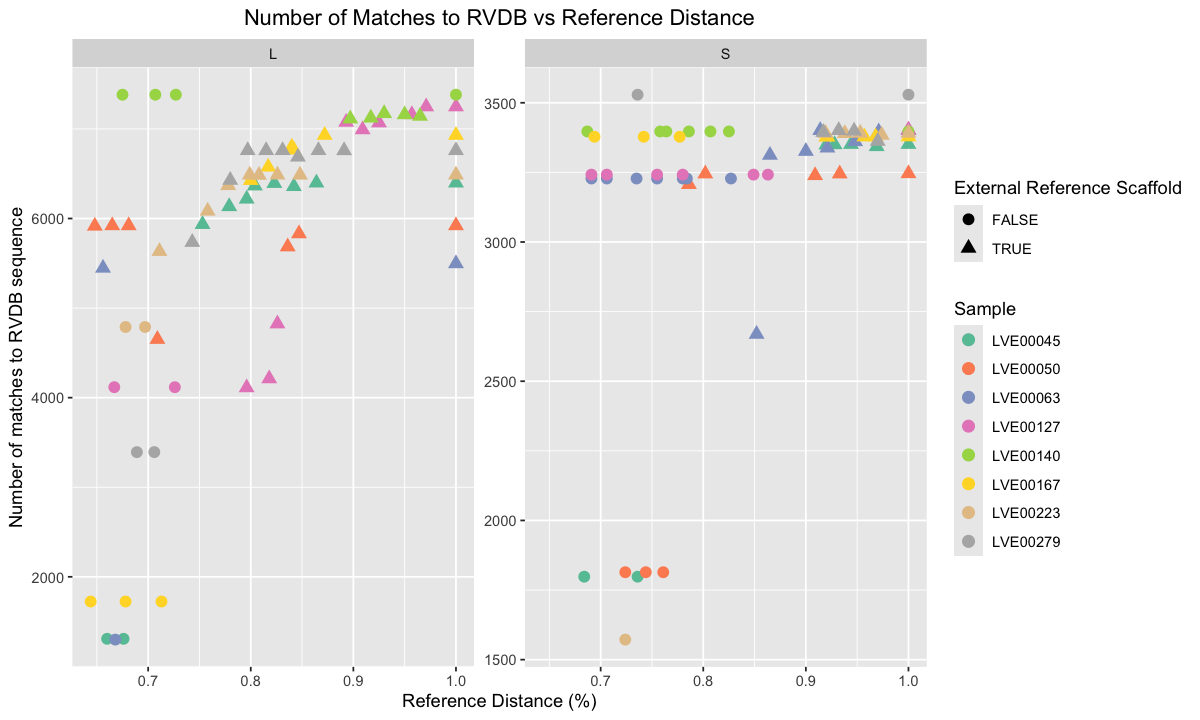

In [207]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free_y") +
    labs(x="Reference Distance (%)", y="Number of matches to RVDB sequence", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Matches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


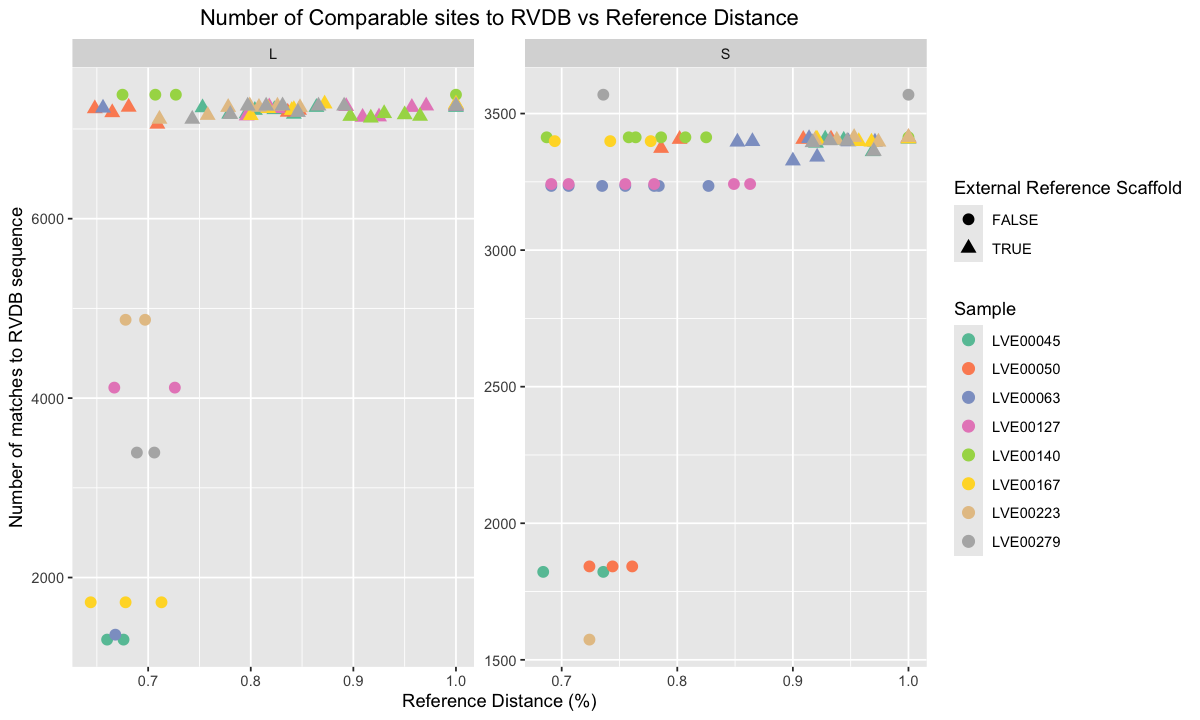

In [208]:
ggplot(consensus_vs_reference, aes(x=fident, y=comparable_sites, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of matches to RVDB sequence", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Comparable sites to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


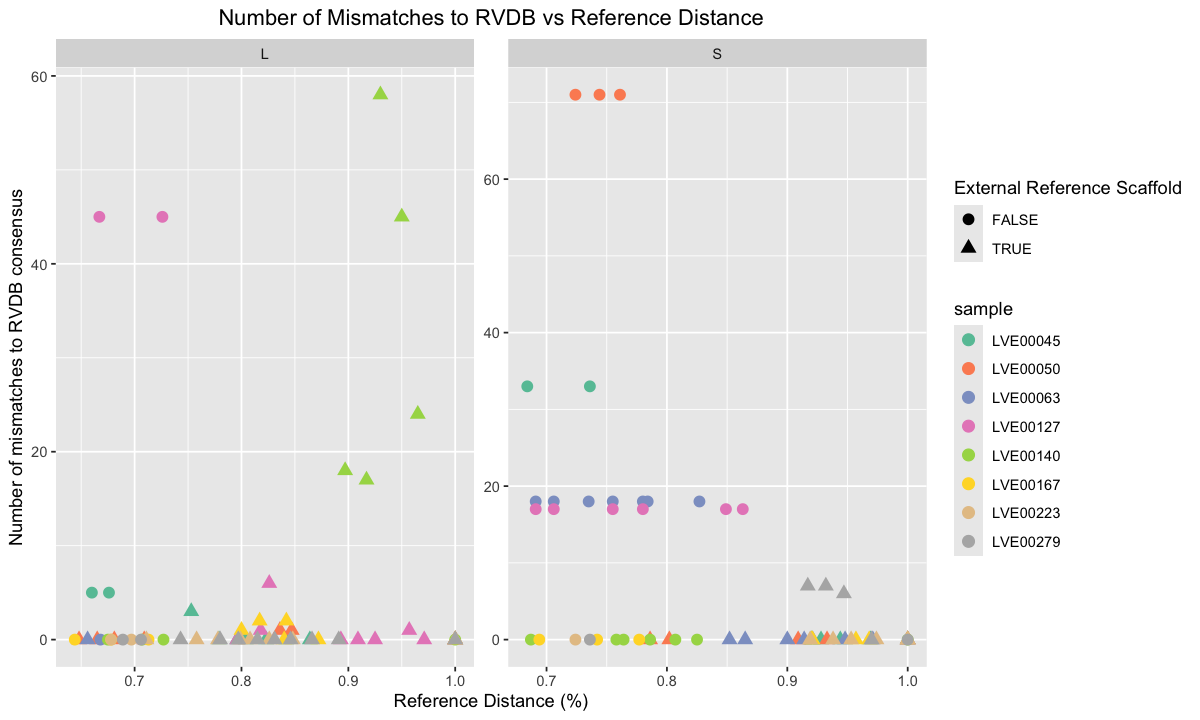

In [200]:
ggplot(consensus_vs_reference, aes(x=fident, y=mismatches,  color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of mismatches to RVDB consensus", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Mismatches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

These mismatches, are occuring due to poorly aligned end regions of the sequences, or due to consensus end regions.
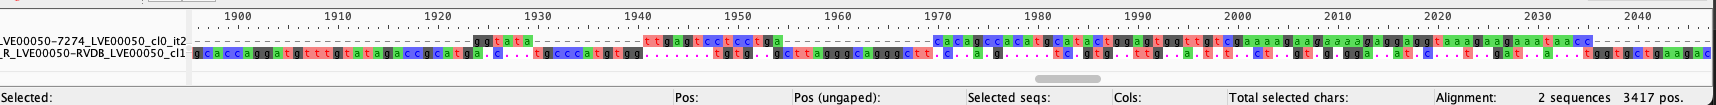
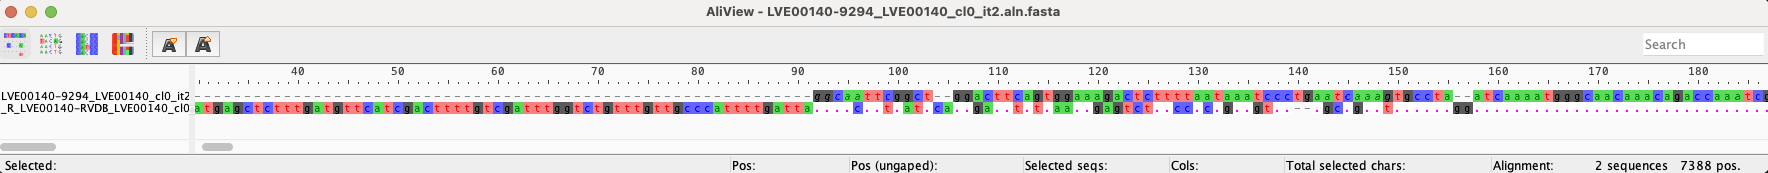


In [209]:
consensus_vs_reference%>%arrange(desc(mismatches))%>%select(mismatches, everything())%>%
    filter(seq1_length > 0.7 * alignment_length)

mismatches,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
<dbl>,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
58,LVE00140_cl0_it2,LVE00140-9294,LVE00140-9294_LVE00140_cl0_it2.consensus_bcftools,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_bcftools,7388,7173,7173,0.008086,7237,⋯,7463,7621,48,7171,7235,0,10566,"(0.92,0.94]",TRUE,FALSE
45,LVE00140_cl0_it2,LVE00140-9496,LVE00140-9496_LVE00140_cl0_it2.consensus_bcftools,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_bcftools,7387,7160,7160,0.006285,7210,⋯,7449,7621,49,7165,7214,0,11181,"(0.94,0.96]",TRUE,FALSE
24,LVE00140_cl0_it2,LVE00140-9698,LVE00140-9698_LVE00140_cl0_it2.consensus_bcftools,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_bcftools,7385,7143,7143,0.003360,7170,⋯,7449,7621,4,7119,7172,0,11836,"(0.96,0.98]",TRUE,FALSE
18,LVE00063_cl0_it2,LVE00063-6668,LVE00063-6668_LVE00063_cl0_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
18,LVE00063_cl0_it2,LVE00063-6870,LVE00063-6870_LVE00063_cl0_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,50,3424,100,3347,3402,0,2363,"(0.68,0.7]",FALSE,FALSE
18,LVE00063_cl0_it2,LVE00063-7072,LVE00063-7072_LVE00063_cl0_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,1658,3424,1338,2979,2979,0,1515,"(0.7,0.72]",FALSE,FALSE
18,LVE00063_cl0_it2,LVE00063-7274,LVE00063-7274_LVE00063_cl0_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,50,3424,1,3248,3303,0,2458,"(0.72,0.74]",FALSE,FALSE
18,LVE00063_cl1_it2,LVE00063-6466,LVE00063-6466_LVE00063_cl1_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
18,LVE00063_cl1_it2,LVE00063-7476,LVE00063-7476_LVE00063_cl1_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3442,3235,3228,0.005564,3286,⋯,50,3424,26,3273,3295,0,2569,"(0.74,0.76]",FALSE,FALSE


Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


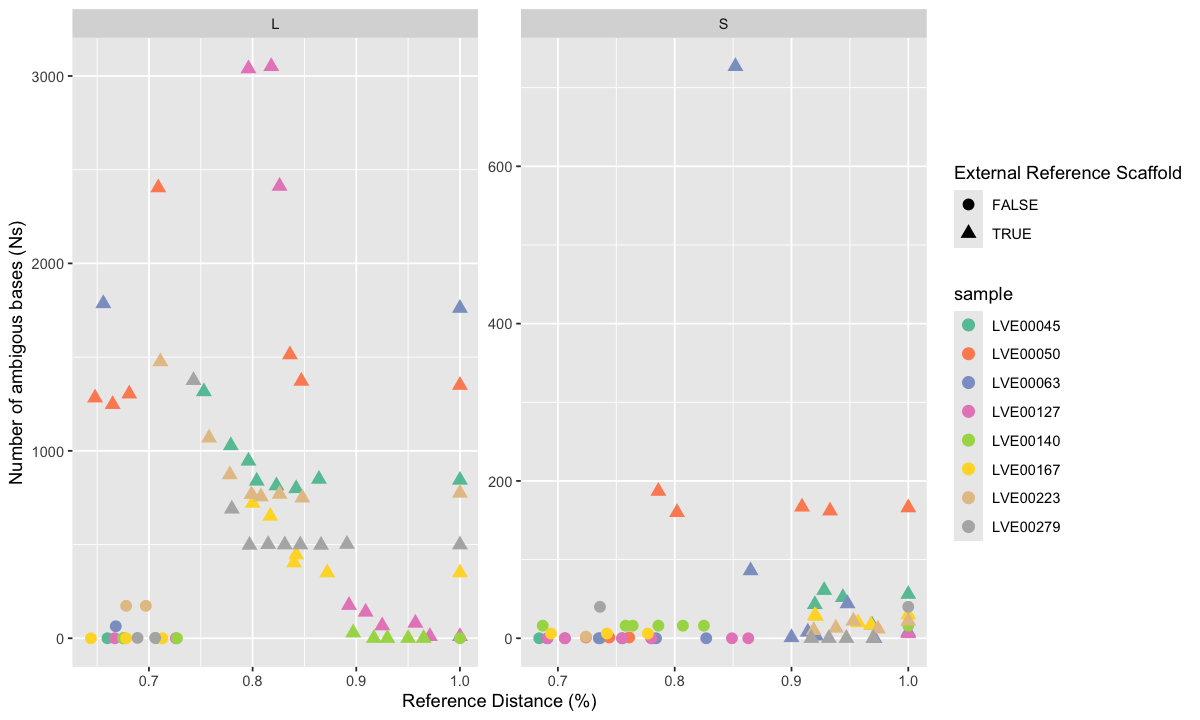

In [210]:
ggplot(consensus_vs_reference, aes(x=fident, y=seq1_Ns, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of ambigous bases (Ns)", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 118 rows containing missing values or values outside the scale range
(`geom_point()`).”


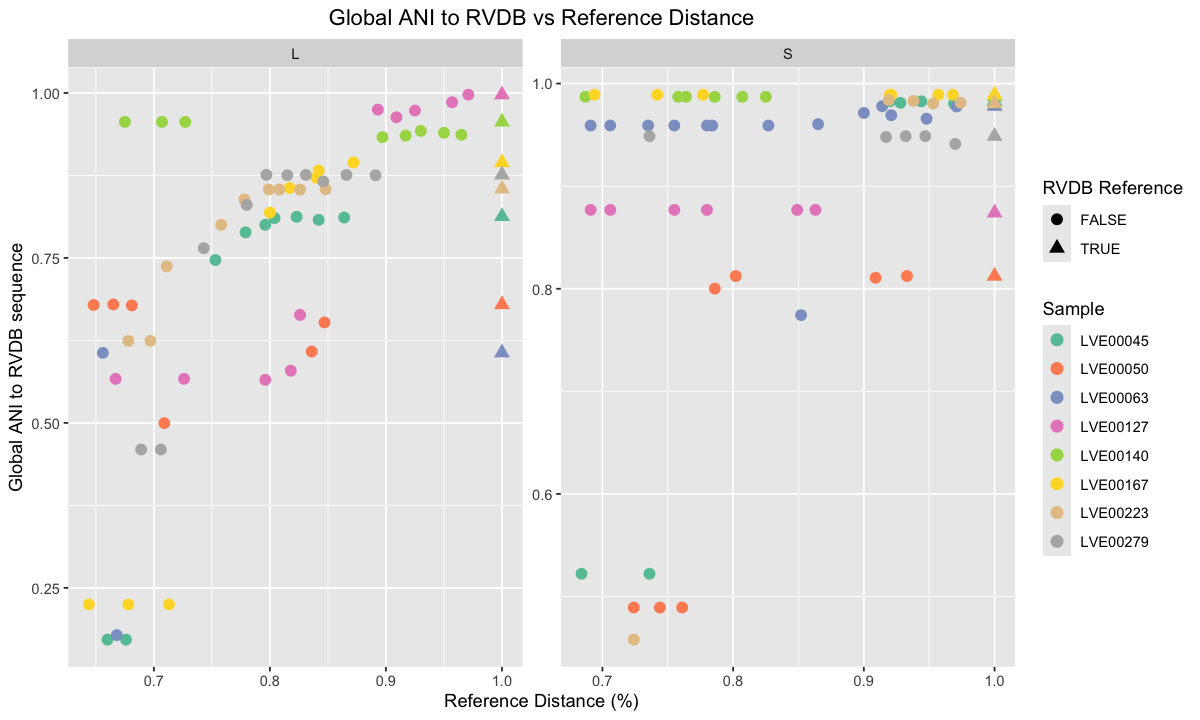

In [119]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_RVDB_reference)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Global ANI to RVDB sequence", color="Sample", shape="RVDB Reference") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

In [218]:
foo <- consensus_vs_reference%>%
    filter(!is_RVDB_reference)%>%
    filter(!is.na(query))%>%
    group_by(query, segment)%>%
    slice_max(order_by = fident, n=1)


# ggplot(consensus_vs_reference, aes(x=fident, y=mism, color=sample, shape=is_RVDB_reference)) +
#     geom_point(size=3) +
#     facet_wrap(~segment, scales = "free") +
#     labs(x="Reference Distance (%)", y="Global ANI to RVDB sequence", color="Sample", shape="RVDB Reference") +
#     scale_color_brewer(palette = "Set2") +
#     ggtitle("Global ANI to RVDB vs Reference Distance") +
#     theme(plot.title = element_text(hjust = 0.5))

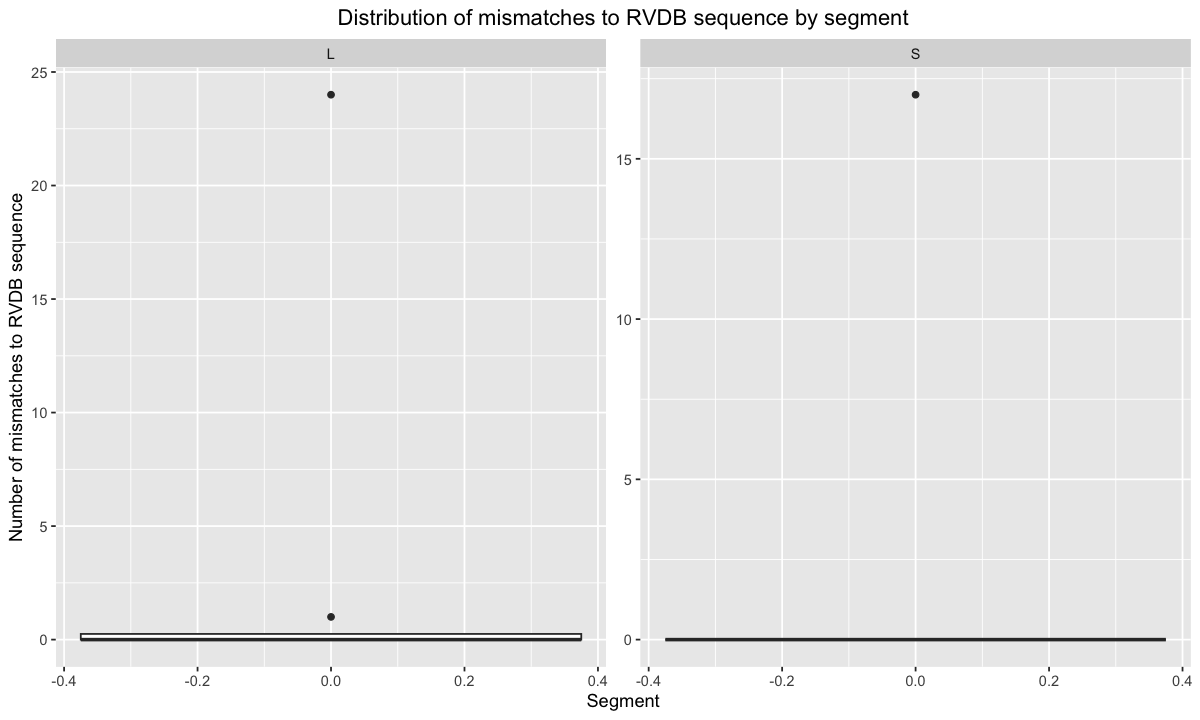

In [223]:
stats_of_interest <- c("matches","mismatches","comparable_sites","seq1_Ns", "seq2_Ns", "seq1_length", "seq2_length", "alignment_length")

ggplot(foo, aes(y=mismatches))+
    geom_boxplot()+
    facet_wrap(~segment, scales="free")+
    labs(y="Number of mismatches to RVDB sequence", x="Segment")+
    ggtitle("Distribution of mismatches to RVDB sequence by segment")+
    theme(plot.title = element_text(hjust = 0.5))

In [224]:
foo%>%arrange(desc(mismatches))%>%select(mismatches, everything())

mismatches,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
<dbl>,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
24,LVE00140_cl0_it2,LVE00140-9698,LVE00140-9698_LVE00140_cl0_it2.consensus_bcftools,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_bcftools,7385,7143,7143,0.003360,7170,⋯,7449,7621,4,7119,7172,0.000e+00,11836,"(0.96,0.98]",TRUE,FALSE
17,LVE00127_cl2_it2,LVE00127-8688,LVE00127-8688_LVE00127_cl2_it2.consensus_bcftools,LVE00127-RVDB_LVE00127_cl1_it2.consensus_bcftools,3497,3242,3242,0.005244,3347,⋯,3303,3817,13,3317,3400,0.000e+00,3890,"(0.86,0.88]",FALSE,FALSE
1,LVE00050_cl0_it2,LVE00050-8486,LVE00050-8486_LVE00050_cl0_it2.consensus_bcftools,LVE00050-RVDB_LVE00050_cl0_it2.consensus_bcftools,7275,7210,5831,0.000139,7215,⋯,2254,7273,51,2230,7214,0.000e+00,2884,"(0.84,0.86]",TRUE,FALSE
0,LVE00045_cl0_it2,LVE00045-8688,LVE00045-8688_LVE00045_cl0_it2.consensus_bcftools,LVE00045-RVDB_LVE00045_cl0_it2.consensus_bcftools,7258,7242,6398,0.000000,7258,⋯,6824,7241,59,6837,7258,0.000e+00,10484,"(0.86,0.88]",TRUE,FALSE
0,LVE00045_cl0_it2,LVE00045-9698,LVE00045-9698_LVE00045_cl0_it2.consensus_bcftools,LVE00045-RVDB_LVE00045_cl1_it2.consensus_bcftools,3407,3361,3343,0.000000,3361,⋯,3383,3407,1,3359,3363,0.000e+00,5600,"(0.96,0.98]",TRUE,FALSE
0,LVE00050_cl0_it2,LVE00050-9294,LVE00050-9294_LVE00050_cl0_it2.consensus_bcftools,LVE00050-RVDB_LVE00050_cl1_it2.consensus_bcftools,3412,3407,3245,0.000000,3407,⋯,3565,3592,1630,3381,3408,0.000e+00,2747,"(0.92,0.94]",TRUE,FALSE
0,LVE00063_cl1_it2,LVE00063-6668,LVE00063-6668_LVE00063_cl1_it2.consensus_bcftools,_R_LVE00063-RVDB_LVE00063_cl0_it2.consensus_bcftools,7258,1363,1299,0.000000,1363,⋯,695,7258,5183,6587,7257,1.344e-212,740,"(0.66,0.68]",FALSE,FALSE
0,LVE00063_cl0_it2,LVE00063-9698,LVE00063-9698_LVE00063_cl0_it2.consensus_bcftools,LVE00063-RVDB_LVE00063_cl1_it2.consensus_bcftools,3409,3396,3396,0.000000,3396,⋯,3353,3424,17,3370,3397,0.000e+00,5600,"(0.96,0.98]",TRUE,FALSE
0,LVE00127_cl0_it2,LVE00127-9698,LVE00127-9698_LVE00127_cl0_it2.consensus_bcftools,LVE00127-RVDB_LVE00127_cl0_it2.consensus_bcftools,7258,7258,7248,0.000000,7258,⋯,7246,7258,1,7246,7258,0.000e+00,12073,"(0.96,0.98]",TRUE,FALSE
